In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [2]:
# Load Dataset and Split to test and train
df = pd.read_csv(f"../data/processed/az-628_expression_response.csv")

non_gene_cols = [
    'IDs', 'Drug.Name', 'ModelID', 'Response',
    'screen', 'dose', 'repurposing_target', 'MOA', 'Synonyms'
]

X = df.drop(columns=[col for col in non_gene_cols if col in df.columns])
y = df['Response']

X = X.select_dtypes(include='number')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

feature_pipeline = joblib.load("../models/feature_pipeline.pkl")

X_train_processed = feature_pipeline.transform(X_train)
X_val_processed = feature_pipeline.transform(X_val)

print(X_train_processed.shape)
print(X_val_processed.shape)


(1539, 2000)
(385, 2000)


In [3]:
# Evaluation function:
def evaluate_model(model_name, model, X_train, X_val, y_train, y_val):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    return {
        "Model": model_name,
        "RMSE": rmse,
        "R2": r2
    }


In [4]:
# Models
models = {
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "SVR": SVR(kernel='rbf'),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    )
}

In [5]:
# Train and eval all models
results = []

for name, model in models.items():
    print(f"Training {name}...")
    result = evaluate_model(
        name,
        model,
        X_train_processed,
        X_val_processed,
        y_train,
        y_val
    )
    results.append(result)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE")

results_df.to_csv(f"../models/az-628_model_comparison_results.csv", index=False)

results_df

Training Ridge...
Training Random Forest...
Training SVR...
Training XGBoost...


,Model,RMSE,R2
2,SVR,0.940349,0.392013
1,Random Forest,0.969523,0.353703
3,XGBoost,1.037561,0.259810
0,Ridge,1.101737,0.165413


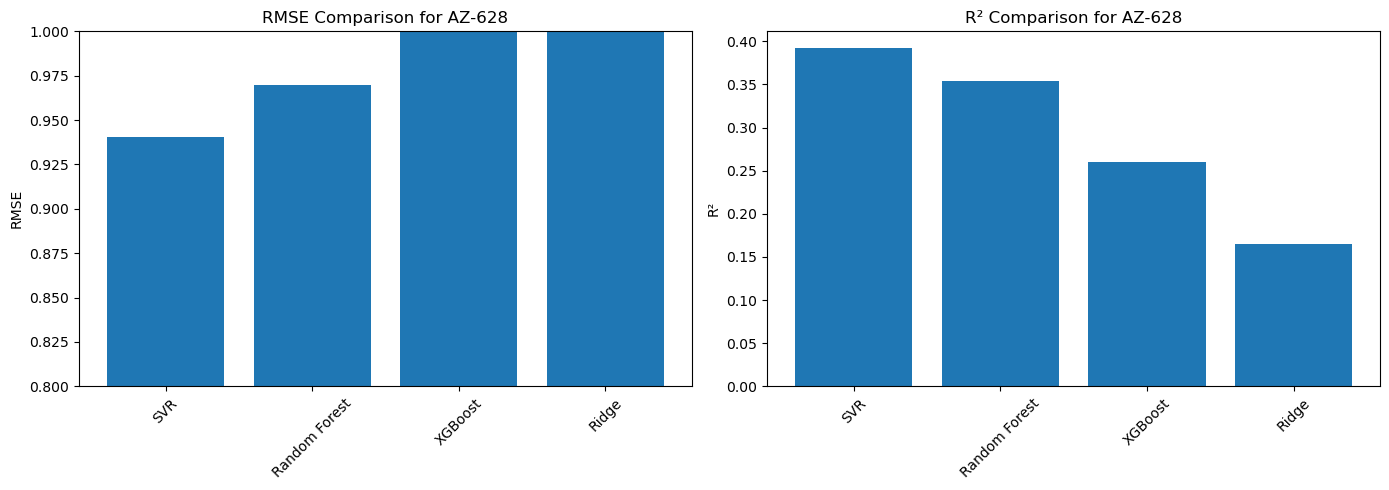

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE plot
axes[0].bar(results_df["Model"], results_df["RMSE"])
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE Comparison for AZ-628")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0.8, 1)  # keep your zoom

# R² plot
axes[1].bar(results_df["Model"], results_df["R2"])
axes[1].set_ylabel("R²")
axes[1].set_title("R² Comparison for AZ-628")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Model Comparison

In this notebook, I compared several regression models using the same train/test split and preprocessing pipeline. The models tested were Ridge Regression, ElasticNet, Random Forest, SVR, and XGBoost. 

The goal was not to tune hyperparameters yet, but to identify which model types performed best using default or basic settings. RMSE and R² were used to compare performance. The two strongest-performing models from this notebook will be selected for hyperparameter tuning in the next notebook.